# The Rise of Generative AI in Online Discourse: A Reddit-Based Social Media Analysis

**Course:** Social Media Mining – Assignment 3  
**Student:** Surya Teja Mothukuri  
**Institution:** Indiana University Bloomington  
**Semester:** Spring 2026  

---

## 1. Project Overview

This notebook implements the complete data collection and analysis pipeline for my final project on generative AI discourse on Reddit. The goal is to understand **how people discuss generative AI tools** (such as ChatGPT, Midjourney, and Stable Diffusion) across different Reddit communities and how these discussions **change over time**.

Specifically, this study focuses on:

- What topics and themes emerge in Reddit discussions about generative AI.  
- How the **sentiment and emotional tone** of these discussions evolve between late 2022 and early 2025.  
- How different Reddit communities (technical, creative, general-interest) **frame generative AI differently** in terms of innovation, ethics, creativity, and societal impact.

The analysis combines **social media data collection**, **natural language processing**, and **computational social science methods** to examine generative AI as a social phenomenon rather than only a technical artifact.

In [73]:
# 1.2 Basic Setup and Imports

import os
import sys
import math
import random
from datetime import datetime

import seaborn as sns
import numpy as np
import pandas as pd

# We will use these later; it's okay if not used immediately
import matplotlib.pyplot as plt

# Set plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Reproducibility: set seeds for random operations
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create a simple project folder structure if it does not exist
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Data directory    :", DATA_DIR)
print("Figures directory :", FIG_DIR)
print("Random seed       :", RANDOM_SEED)

Working directory: /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone
Data directory    : /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data
Figures directory : /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/figures
Random seed       : 42


## 2. Data Collection Plan

The empirical foundation of this project is a self-collected Reddit dataset focused on discussions about generative AI. Reddit is chosen because it hosts diverse, topic-specific communities (subreddits) where users engage in longer, threaded conversations rather than short, isolated messages. This makes it a suitable platform for analyzing how people collectively interpret and negotiate the impact of generative AI tools.

### 2.1 Target Platform and Communities

The dataset will be constructed from multiple subreddits that frequently discuss generative AI, including both technical and non-technical communities. In particular, I focus on:

- **r/ChatGPT** – General discussions, tips, and experiences using ChatGPT.  
- **r/Midjourney** – Creative and artistic uses of the Midjourney image generation model.  
- **r/StableDiffusion** – Technical and creative discussions around Stable Diffusion.  
- **r/ArtificialIntelligence** – Broader AI news, opinions, and conceptual debates.  
- **r/MachineLearning** – More technical and research-oriented discussions.  
- **r/technology** – General technology news and debates where generative AI often appears.

These communities allow comparison between **creative**, **technical**, and **general-interest** perspectives on generative AI.

In [74]:
# 2.5 Configuration: Subreddits, Time Range, and File Paths

# Target subreddits (grouped for clarity if needed later)
SUBREDDITS = [
    "ChatGPT",
    "Midjourney",
    "StableDiffusion",
    "OpenAI",
    "ArtificialInteligence",  # that weird spelling one
    "artificial",
    "MachineLearning",
    "technology",
    "Futurology",
]

# Instead of 2022–2025, use a recent window, e.g. last 4–5 months
DATE_FROM = "2025-01-01"
DATE_TO   = "2025-11-30"

DATE_FROM_DT = datetime.fromisoformat(DATE_FROM)
DATE_TO_DT   = datetime.fromisoformat(DATE_TO)

print("Updated date range:", DATE_FROM, "to", DATE_TO)

print("Target subreddits:", SUBREDDITS)
print("Date range      :", DATE_FROM, "to", DATE_TO)

# File paths for saving raw and processed data
RAW_POSTS_PATH    = os.path.join(DATA_DIR, "raw_posts.csv")
RAW_COMMENTS_PATH = os.path.join(DATA_DIR, "raw_comments.csv")

CLEAN_POSTS_PATH    = os.path.join(DATA_DIR, "clean_posts.csv")
CLEAN_COMMENTS_PATH = os.path.join(DATA_DIR, "clean_comments.csv")

print("Raw posts file   :", RAW_POSTS_PATH)
print("Raw comments file:", RAW_COMMENTS_PATH)

Updated date range: 2025-01-01 to 2025-11-30
Target subreddits: ['ChatGPT', 'Midjourney', 'StableDiffusion', 'OpenAI', 'ArtificialInteligence', 'artificial', 'MachineLearning', 'technology', 'Futurology']
Date range      : 2025-01-01 to 2025-11-30
Raw posts file   : /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/raw_posts.csv
Raw comments file: /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/raw_comments.csv


## 3. Reddit Data Collection – Posts (Public JSON API)

Because access to Reddit's official API now requires an additional approval process that may not complete within the course timeline, this project uses Reddit's **public JSON endpoints** to collect data instead of authenticated API calls.

Reddit exposes a JSON representation of search results and posts that can be accessed without authentication, as long as requests:

- Only target publicly available content  
- Respect reasonable rate limits  
- Include a descriptive `User-Agent` header  

In this section, I collect posts from the target subreddits defined in Section 2 by querying the search endpoint:

`https://www.reddit.com/r/<subreddit>/search.json`

for generative AI–related keywords (e.g., "chatgpt", "gpt-4", "midjourney", "stable diffusion") and then filtering by the project’s date range. The resulting dataset is saved as `raw_posts.csv` for further cleaning and analysis.

In [75]:
# 3.1 Additional imports for HTTP requests and progress bars

# !pip install tqdm requests  # Uncomment if not already installed

import requests
import time
from typing import List, Dict
from tqdm.auto import tqdm

In [76]:
# 3.2 Generative AI-related keywords and HTTP headers

GAI_KEYWORDS = [
    "chatgpt",
    "gpt-4",
    "gpt4",
    "gpt 4",
    "gpt-3.5",
    "midjourney",
    "stable diffusion",
    "stablediffusion",
    "dall-e",
    "dalle",
    "dall e",
    "generative ai",
    "large language model",
    "llm",
    "image generation",
]

# Reddit requires a meaningful User-Agent string
HEADERS = {
    "User-Agent": "generative-ai-research-assignment3 by u-iu_student"
}

print("Generative AI keywords:", GAI_KEYWORDS)
print("Headers:", HEADERS)

Generative AI keywords: ['chatgpt', 'gpt-4', 'gpt4', 'gpt 4', 'gpt-3.5', 'midjourney', 'stable diffusion', 'stablediffusion', 'dall-e', 'dalle', 'dall e', 'generative ai', 'large language model', 'llm', 'image generation']
Headers: {'User-Agent': 'generative-ai-research-assignment3 by u-iu_student'}


In [77]:
# 3.3 Helper: check if a UNIX timestamp falls within [DATE_FROM_DT, DATE_TO_DT]

def in_date_range(created_utc: float) -> bool:
    dt = datetime.utcfromtimestamp(created_utc)
    return DATE_FROM_DT <= dt <= DATE_TO_DT

### 3.4 Search Strategy using `search.json`

Reddit's public search JSON endpoint supports queries such as:

`https://www.reddit.com/r/<subreddit>/search.json?q=<query>&sort=new&restrict_sr=on&limit=100&syntax=lucene&t=all`

To construct a focused generative AI dataset, the script:

1. Builds a search query combining multiple keywords with `OR` (e.g., `"chatgpt" OR "gpt-4" OR "midjourney"`).  
2. Fetches matching posts in batches (up to 100 per request) sorted by `new`.  
3. Uses the `after` parameter from Reddit's pagination to continue retrieving older posts.  
4. For each post:
   - Extracts key fields (ID, subreddit, title, selftext, score, comment count, timestamp, URL).  
   - Filters posts by the target date range (2022-11-01 to 2025-01-31).  
5. Stops when either:
   - No more results are returned, or  
   - A maximum post limit for that subreddit is reached.

This approach may not capture **every** post ever made, but it constructs a systematic and reproducible sample of generative AI discussions for each subreddit.

In [78]:
from datetime import timezone

BASE_URL = "https://www.reddit.com"

def collect_posts_from_feed(
    subreddit: str,
    max_posts: int = 1200,
    sleep_sec: float = 5.0,
) -> List[Dict]:
    """
    Collect posts from a subreddit's /new feed using Reddit's public JSON endpoint,
    filtered only by date range. For subs like r/ChatGPT or r/Midjourney, most posts
    are inherently about generative AI.
    """
    print(f"\n🔎 Collecting posts from r/{subreddit} via /new.json")
    print(f"   Target date range: {DATE_FROM} to {DATE_TO}")

    url = f"{BASE_URL}/r/{subreddit}/new.json"
    after = None
    collected = []
    seen_ids = set()
    total_requests = 0
    consecutive_429 = 0

    with tqdm(total=max_posts, desc=f"r/{subreddit}", unit="post") as pbar:
        while len(collected) < max_posts:
            params = {"limit": 100}
            if after:
                params["after"] = after

            try:
                resp = requests.get(url, headers=HEADERS, params=params, timeout=20)
            except Exception as e:
                print(f"⚠️ Request error for r/{subreddit}: {e}")
                break

            total_requests += 1

            if resp.status_code == 429:
                consecutive_429 += 1
                wait_time = min(60, 10 * consecutive_429)
                print(f"⏳ Received 429 (Too Many Requests). Sleeping {wait_time} seconds...")
                time.sleep(wait_time)

                if consecutive_429 >= 5:
                    print(f"⚠️ Too many 429s for r/{subreddit}. Stopping early.")
                    break
                continue
            else:
                consecutive_429 = 0

            if resp.status_code == 404:
                print(f"⚠️ r/{subreddit} returned 404 (maybe private, banned, or misspelled). Stopping.")
                break
            elif resp.status_code != 200:
                print(f"⚠️ Non-200 status code {resp.status_code} for r/{subreddit}. Stopping.")
                break

            data = resp.json().get("data", {})
            children = data.get("children", [])
            after = data.get("after", None)

            if not children:
                # No more posts
                break

            for child in children:
                d = child.get("data", {})
                post_id = d.get("id")
                if not post_id or post_id in seen_ids:
                    continue

                created_utc = d.get("created_utc")
                if created_utc is None:
                    continue

                dt = datetime.fromtimestamp(created_utc, tz=timezone.utc)

                # Filter by date range only
                if not (
                    DATE_FROM_DT.replace(tzinfo=timezone.utc)
                    <= dt
                    <= DATE_TO_DT.replace(tzinfo=timezone.utc)
                ):
                    continue

                title = d.get("title", "") or ""
                selftext = d.get("selftext", "") or ""

                post_dict = {
                    "post_id": post_id,
                    "subreddit": subreddit,
                    "title": title,
                    "selftext": selftext,
                    "score": d.get("score", 0),
                    "num_comments": d.get("num_comments", 0),
                    "created_utc": created_utc,
                    "url": f"https://www.reddit.com{d.get('permalink', '')}",
                    "over_18": d.get("over_18", False),
                }

                collected.append(post_dict)
                seen_ids.add(post_id)
                pbar.update(1)

                if len(collected) >= max_posts:
                    break

            if after is None:
                break

            time.sleep(sleep_sec)

    print(f"✅ Collected {len(collected)} posts from r/{subreddit}.")
    print(f"   Total HTTP requests: {total_requests}")
    return collected

In [79]:
all_posts = []

for sub in SUBREDDITS:
    try:
        posts_sub = collect_posts_from_feed(
            subreddit=sub,
            max_posts=1200,    # aim for up to ~1.2k per subreddit
            sleep_sec=6.0,     # be kind to Reddit
        )
        all_posts.extend(posts_sub)
    except Exception as e:
        print(f"⚠️ Error while collecting from r/{sub}: {e}")
        continue

posts_df = pd.DataFrame(all_posts)
print("\nTotal posts collected (before dedup):", len(posts_df))

posts_df.drop_duplicates(subset=["post_id"], inplace=True)
print("Total posts after dedup:", len(posts_df))

posts_df.to_csv(RAW_POSTS_PATH, index=False)
print(f"💾 Saved raw posts to: {RAW_POSTS_PATH}")


🔎 Collecting posts from r/ChatGPT via /new.json
   Target date range: 2025-01-01 to 2025-11-30


r/ChatGPT:   0%|          | 0/1200 [00:00<?, ?post/s]

✅ Collected 945 posts from r/ChatGPT.
   Total HTTP requests: 10

🔎 Collecting posts from r/Midjourney via /new.json
   Target date range: 2025-01-01 to 2025-11-30


r/Midjourney:   0%|          | 0/1200 [00:00<?, ?post/s]

✅ Collected 993 posts from r/Midjourney.
   Total HTTP requests: 11

🔎 Collecting posts from r/StableDiffusion via /new.json
   Target date range: 2025-01-01 to 2025-11-30


...

✅ Collected 947 posts from r/MachineLearning.
   Total HTTP requests: 10

🔎 Collecting posts from r/technology via /new.json
   Target date range: 2025-01-01 to 2025-11-30


r/technology:   0%|          | 0/1200 [00:00<?, ?post/s]

✅ Collected 977 posts from r/technology.
   Total HTTP requests: 10

🔎 Collecting posts from r/Futurology via /new.json
   Target date range: 2025-01-01 to 2025-11-30


r/Futurology:   0%|          | 0/1200 [00:00<?, ?post/s]

✅ Collected 965 posts from r/Futurology.
   Total HTTP requests: 10

Total posts collected (before dedup): 8636
Total posts after dedup: 8636
💾 Saved raw posts to: /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/raw_posts.csv


In [80]:
df = pd.read_csv("/Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/raw_posts.csv")

In [81]:
df

,post_id,subreddit,title,selftext,score,num_comments,created_utc,url,over_18
0,1pa3mx0,ChatGPT,"I cannot stand the ""that's not xyz, it's just ...",How do I make 5.1 stop saying this? Half the t...,35,11,1.764461e+09,https://www.reddit.com/r/ChatGPT/comments/1pa3...,False
1,1pa3lhi,ChatGPT,"Guys, these chatGPT ads are getting out of hand!","You could almost say, they are nano bananas!",8,3,1.764460e+09,https://www.reddit.com/r/ChatGPT/comments/1pa3...,False
2,1pa2y8a,ChatGPT,Excuse me?,No custom instructions either,2,2,1.764459e+09,https://www.reddit.com/r/ChatGPT/comments/1pa2...,False
3,1pa2vgr,ChatGPT,Sora Saturday,So I’m brainstorming marketing ideas for *just...,0,2,1.764458e+09,https://www.reddit.com/r/ChatGPT/comments/1pa2...,False
4,1pa2rwz,ChatGPT,I genuinely hate when I am the one who has to ...,Sorry for the non-AI-made meme.,0,1,1.764458e+09,https://www.reddit.com/r/ChatGPT/comments/1pa2...,False
...,...,...,...,...,...,...,...,...,...
8631,1n9lpyt,Futurology,What kind of world we should expect when boome...,Every generation has their own challenges and ...,0,54,1.757119e+09,https://www.reddit.com/r/Futurology/comments/1...,False
8632,1n9b4rc,Futurology,US researchers have demonstrated a groundbreak...,\nTwo separate discoveries this year have rest...,145,1,1.757093e+09,https://www.reddit.com/r/Futurology/comments/1...,False
8633,1n992pw,Futurology,Strange “heavy” electrons could be the future ...,NaN,63,3,1.757088e+09,https://www.reddit.com/r/Futurology/comments/1...,False
8634,1n96i7t,Futurology,"How cutting US air pollution could save 6,000 ...",NaN,283,22,1.757082e+09,https://www.reddit.com/r/Futurology/comments/1...,False


## 4. Reddit Data Collection – Comments

Posts provide the initial prompts around generative AI, but the **comment threads** reveal how communities react, negotiate meaning, and debate implications. To analyze this conversational layer, I collect comments for the posts stored in `raw_posts.csv`.

Reddit exposes a public JSON representation of each discussion thread at:

`<post_url>.json`

For each post in the dataset, I:

1. Request `<post_url>.json` using an anonymous HTTP GET with a descriptive User-Agent.  
2. Extract the comment tree returned in the second element of the JSON list.  
3. Traverse the tree recursively to collect individual comments.  
4. Store key metadata (comment ID, parent ID, post ID, subreddit, author, score, timestamp, and body text).  
5. Optionally cap the number of comments per post to keep the dataset tractable and to respect rate limiting.

All comments are stored in a flat table, `raw_comments.csv`, which is later cleaned and used for sentiment and topic analysis.

In [82]:
# 4.1 Load the raw posts and configure comment scraping

posts_df = pd.read_csv(RAW_POSTS_PATH)
print("Posts dataframe shape:", posts_df.shape)

# Optional: prioritize posts with more comments first
posts_df = posts_df.sort_values("num_comments", ascending=False).reset_index(drop=True)

# Configuration for comment collection
MAX_POSTS_FOR_COMMENTS   = 1500   # how many posts to fetch comments for (from the top)
MAX_COMMENTS_PER_POST    = 200    # safety cap per post
COMMENT_SLEEP_SEC        = 3.0    # base sleep between posts
MAX_429_RETRIES_PER_POST = 3      # how many times to tolerate 429 for one post
GLOBAL_COMMENT_LIMIT = 110000


print("We will attempt to fetch comments for up to",
      min(MAX_POSTS_FOR_COMMENTS, len(posts_df)), "posts.")

Posts dataframe shape: (8636, 9)
We will attempt to fetch comments for up to 1500 posts.


In [83]:
# 4.2 Helper: fetch the JSON thread for a single post URL

def fetch_post_thread_json(post_url: str):
    """
    Fetch the JSON thread for a Reddit post.
    Returns:
        list or None: The parsed JSON (a list with [post_listing, comment_listing])
                      or None if the request fails.
    """
    # Ensure the URL ends with a slash before appending .json
    if not post_url.endswith("/"):
        post_url = post_url.rstrip("/") + "/"
    json_url = post_url + ".json"

    try:
        resp = requests.get(json_url, headers=HEADERS, timeout=20)
    except Exception as e:
        print(f"⚠️ HTTP error for {post_url}: {e}")
        return None

    if resp.status_code == 429:
        # Caller will handle 429 logic
        return "429"
    if resp.status_code != 200:
        print(f"⚠️ Non-200 status code {resp.status_code} for {post_url}")
        return None

    try:
        data = resp.json()
        return data
    except Exception as e:
        print(f"⚠️ JSON parse error for {post_url}: {e}")
        return None

In [84]:
# 4.3 Helper: flatten the nested comment tree into a list of dicts

def flatten_comments(children, post_id: str, subreddit: str, comments_acc: List[Dict]):
    """
    Recursively traverse the 'children' list from Reddit's JSON and
    append comment dicts to comments_acc.
    """
    if not isinstance(children, list):
        return

    for child in children:
        kind = child.get("kind")
        data = child.get("data", {})

        # 't1' = comment, 'more' = placeholders for more comments (skip 'more')
        if kind == "t1":
            comment_id = data.get("id")
            if not comment_id:
                continue

            body = data.get("body", "")
            created_utc = data.get("created_utc")
            if created_utc is None:
                continue

            comment_dict = {
                "comment_id": comment_id,
                "post_id": post_id,
                "subreddit": subreddit,
                "parent_id": data.get("parent_id", ""),
                "body": body,
                "score": data.get("score", 0),
                "created_utc": created_utc,
                "author": data.get("author", ""),
                "is_submitter": data.get("is_submitter", False),
            }

            comments_acc.append(comment_dict)

            # Recurse into replies (if any)
            replies = data.get("replies")
            if isinstance(replies, dict):
                repl_children = replies.get("data", {}).get("children", [])
                flatten_comments(repl_children, post_id, subreddit, comments_acc)

        # Skip 'more' kinds or unknown kinds silently

In [85]:
# 4.4 Collect comments for top N posts and save to CSV

all_comments = []

num_target_posts = min(MAX_POSTS_FOR_COMMENTS, len(posts_df))

for idx in tqdm(range(num_target_posts), desc="Collecting comments", unit="post"):
    row = posts_df.iloc[idx]
    post_id = row["post_id"]
    subreddit = row["subreddit"]
    post_url = row["url"]

    retries_429 = 0

    while True:
        data = fetch_post_thread_json(post_url)

        if data == "429":
            retries_429 += 1
            wait_time = min(60, 10 * retries_429)
            print(f"\n⏳ 429 for post {post_id}, sleeping {wait_time} seconds (attempt {retries_429})...")
            time.sleep(wait_time)
            if retries_429 >= MAX_429_RETRIES_PER_POST:
                print(f"⚠️ Too many 429s for post {post_id}. Skipping this thread.")
                data = None
                break
            continue

        break

    if data is None:
        continue

    if not isinstance(data, list) or len(data) < 2:
        continue

    comments_listing = data[1]
    children = comments_listing.get("data", {}).get("children", [])

    comments_acc = []
    flatten_comments(children, post_id=post_id, subreddit=subreddit, comments_acc=comments_acc)

    if len(comments_acc) > MAX_COMMENTS_PER_POST:
        comments_acc = comments_acc[:MAX_COMMENTS_PER_POST]

    # Add new comments
    all_comments.extend(comments_acc)

    # 🔴 STOP if global limit reached
    if len(all_comments) >= GLOBAL_COMMENT_LIMIT:
        print(f"\n🛑 Reached GLOBAL limit of {GLOBAL_COMMENT_LIMIT} comments. Stopping early.\n")
        break

    time.sleep(COMMENT_SLEEP_SEC)

# Extra break safety
if len(all_comments) >= GLOBAL_COMMENT_LIMIT:
    print("🛑 Global limit reached — exiting comment collection.")

comments_df = pd.DataFrame(all_comments)
print("Total comments collected (before dedup):", len(comments_df))

# Drop duplicates just in case
comments_df.drop_duplicates(subset=["comment_id"], inplace=True)
print("Total comments after dedup:", len(comments_df))

# Save to CSV
comments_df.to_csv(RAW_COMMENTS_PATH, index=False)
print(f"💾 Saved raw comments to: {RAW_COMMENTS_PATH}")


⏳ 429 for post 1nn9c0w, sleeping 10 seconds (attempt 1)...

⏳ 429 for post 1nn9c0w, sleeping 20 seconds (attempt 2)...

⏳ 429 for post 1nn9c0w, sleeping 30 seconds (attempt 3)...
⚠️ Too many 429s for post 1nn9c0w. Skipping this thread.

⏳ 429 for post 1osj10y, sleeping 10 seconds (attempt 1)...

⏳ 429 for post 1osj10y, sleeping 20 seconds (attempt 2)...

⏳ 429 for post 1nmpkc1, sleeping 10 seconds (attempt 1)...

⏳ 429 for post 1nmpkc1, sleeping 20 seconds (attempt 2)...

⏳ 429 for post 1nmpkc1, sleeping 30 seconds (attempt 3)...
⚠️ Too many 429s for post 1nmpkc1. Skipping this thread.

⏳ 429 for post 1nw9zym, sleeping 10 seconds (attempt 1)...

⏳ 429 for post 1nw9zym, sleeping 20 seconds (attempt 2)...

⏳ 429 for post 1nw9zym, sleeping 30 seconds (attempt 3)...
⚠️ Too many 429s for post 1nw9zym. Skipping this thread.

⏳ 429 for post 1o6zy6k, sleeping 10 seconds (attempt 1)...

⏳ 429 for post 1o6zy6k, sleeping 20 seconds (attempt 2)...

⏳ 429 for post 1o6zy6k, sleeping 30 seconds (att

In [86]:
df = pd.read_csv("/Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/raw_comments.csv")

In [87]:
df

,comment_id,post_id,subreddit,parent_id,body,score,created_utc,author,is_submitter
0,npyvyp9,1p2osv5,technology,t3_1p2osv5,"*Wants an operating system, you know like run ...",7317,1.763699e+09,MaliciousTent,False
1,npyxyh7,1p2osv5,technology,t1_npyvyp9,&gt; *Can I just write a document in peace?\n\...,2054,1.763700e+09,Mother_Idea_3182,False
2,npzpock,1p2osv5,technology,t1_npyxyh7,Don't you love when the bloated software that ...,1094,1.763714e+09,KevinFlantier,False
3,nq08wca,1p2osv5,technology,t1_npzpock,"What gets me is not even the bloat, that tends...",608,1.763725e+09,Wischiwaschbaer,False
4,nq0bktu,1p2osv5,technology,t1_nq08wca,The worst part is that they keep moving things...,360,1.763727e+09,KevinFlantier,False
...,...,...,...,...,...,...,...,...,...
110106,nmcoj1a,1okrhdq,Futurology,t1_nmcoc5l,We are headed for electric vehicles but we hav...,-3,1.761910e+09,Im_2_high,True
110107,nmcp97x,1okrhdq,Futurology,t1_nmcoj1a,We're not that close to running out of oil. El...,1,1.761910e+09,Dense_Information813,False
110108,nmcqo0v,1okrhdq,Futurology,t1_nmcp97x,I know we might not ever need it but its a tho...,1,1.761911e+09,Im_2_high,True
110109,nmcru3b,1okrhdq,Futurology,t3_1okrhdq,"Honestly, it's a bad idea.\n\nIt will be easie...",-1,1.761911e+09,noahjsc,False


In [152]:
posts_raw['created_dt'] = pd.to_datetime(posts_raw['created_utc'], unit='s')
comments_raw['created_dt'] = pd.to_datetime(comments_raw['created_utc'], unit='s')

print("Earliest POST date:", posts_raw['created_dt'].min())
print("Earliest COMMENT date:", comments_raw['created_dt'].min())

Earliest POST date: 2025-07-19 15:06:29
Earliest COMMENT date: 2025-07-23 10:11:14


## 5. Data Cleaning and Preprocessing

Before analyzing discourse patterns, the raw Reddit data needs to be cleaned and transformed into a consistent, analysis-ready format. In this section, I:

1. Load the collected posts and comments from `raw_posts.csv` and `raw_comments.csv`.  
2. Remove clearly non-informative records, such as posts or comments with deleted or empty text.  
3. Normalize time information by converting timestamps into timezone-aware datetime objects.  
4. Create basic derived features, including text length and a binary flag for whether the text explicitly mentions generative AI tools (e.g., “ChatGPT”, “GPT-4”, “Midjourney”).  
5. Save cleaned versions of both tables for subsequent exploratory analysis, sentiment analysis, and topic modeling.

In [88]:
# 5.1 Load raw posts and comments

posts_raw = pd.read_csv(RAW_POSTS_PATH)
comments_raw = pd.read_csv(RAW_COMMENTS_PATH)

print("Raw posts shape   :", posts_raw.shape)
print("Raw comments shape:", comments_raw.shape)

posts_raw.head(2), comments_raw.head(2)

Raw posts shape   : (8636, 9)
Raw comments shape: (110111, 9)


(   post_id subreddit                                              title  \
 0  1pa3mx0   ChatGPT  I cannot stand the "that's not xyz, it's just ...   
 1  1pa3lhi   ChatGPT   Guys, these chatGPT ads are getting out of hand!   
 
                                             selftext  score  num_comments  \
 0  How do I make 5.1 stop saying this? Half the t...     35            11   
 1       You could almost say, they are nano bananas!      8             3   
 
     created_utc                                                url  over_18  
 0  1.764461e+09  https://www.reddit.com/r/ChatGPT/comments/1pa3...    False  
 1  1.764460e+09  https://www.reddit.com/r/ChatGPT/comments/1pa3...    False  ,
   comment_id  post_id   subreddit   parent_id  \
 0    npyvyp9  1p2osv5  technology  t3_1p2osv5   
 1    npyxyh7  1p2osv5  technology  t1_npyvyp9   
 
                                                 body  score   created_utc  \
 0  *Wants an operating system, you know like run ...   7317  1.76

In [89]:
# 5.2 Helper functions for cleaning

import re
from datetime import timezone

# Reuse your generative AI keywords but in a form suitable for regex matching
GAI_KEYWORDS = [
    "chatgpt",
    "gpt-4",
    "gpt4",
    "gpt 4",
    "gpt-3.5",
    "midjourney",
    "stable diffusion",
    "stablediffusion",
    "dall-e",
    "dalle",
    "dall e",
    "generative ai",
    "large language model",
    "llm",
    "image generation",
]

# Compile a regex for quick matching (case-insensitive)
GAI_PATTERN = re.compile(
    "|".join(re.escape(kw.lower()) for kw in GAI_KEYWORDS),
    flags=re.IGNORECASE,
)

def normalize_text(text: str) -> str:
    """Basic normalization: ensure string, strip whitespace."""
    if not isinstance(text, str):
        return ""
    return text.strip()

def contains_gai_keyword(text: str) -> bool:
    """Return True if text contains any generative-AI keyword."""
    if not isinstance(text, str) or not text:
        return False
    return bool(GAI_PATTERN.search(text))

In [90]:
# 5.3 Clean posts

posts = posts_raw.copy()

# Normalize title and selftext
posts["title"] = posts["title"].apply(normalize_text)
posts["selftext"] = posts["selftext"].apply(normalize_text)

# Combine title + body for later NLP
posts["text"] = (posts["title"] + " " + posts["selftext"]).str.strip()

# Remove posts with empty or deleted content
mask_informative = ~posts["text"].str.lower().isin(["", "[deleted]", "[removed]"])
posts = posts[mask_informative].copy()

# Convert created_utc to datetime (UTC)
posts["created_dt"] = posts["created_utc"].apply(
    lambda ts: datetime.fromtimestamp(ts, tz=timezone.utc)
)

# Text length feature
posts["text_len"] = posts["text"].str.len()

# Flag whether post explicitly mentions a generative-AI keyword
posts["mentions_gai"] = posts["text"].apply(contains_gai_keyword)

print("Clean posts shape:", posts.shape)
posts.head(3)

Clean posts shape: (8636, 13)


,post_id,subreddit,title,selftext,score,num_comments,created_utc,url,over_18,text,created_dt,text_len,mentions_gai
0,1pa3mx0,ChatGPT,"I cannot stand the ""that's not xyz, it's just ...",How do I make 5.1 stop saying this? Half the t...,35,11,1.764461e+09,https://www.reddit.com/r/ChatGPT/comments/1pa3...,False,"I cannot stand the ""that's not xyz, it's just ...",2025-11-29 23:55:27+00:00,327,False
1,1pa3lhi,ChatGPT,"Guys, these chatGPT ads are getting out of hand!","You could almost say, they are nano bananas!",8,3,1.764460e+09,https://www.reddit.com/r/ChatGPT/comments/1pa3...,False,"Guys, these chatGPT ads are getting out of han...",2025-11-29 23:53:35+00:00,93,True
2,1pa2y8a,ChatGPT,Excuse me?,No custom instructions either,2,2,1.764459e+09,https://www.reddit.com/r/ChatGPT/comments/1pa2...,False,Excuse me? No custom instructions either,2025-11-29 23:24:10+00:00,40,False


In [115]:
# 5.4 Clean comments

comments = comments_raw.copy()

# Normalize body
comments["body"] = comments["body"].apply(normalize_text)

# Remove clearly non-informative comments
mask_informative_c = ~comments["body"].str.lower().isin(["", "[deleted]", "[removed]"])
comments = comments[mask_informative_c].copy()

# Convert created_utc to datetime (UTC)
comments["created_dt"] = comments["created_utc"].apply(
    lambda ts: datetime.fromtimestamp(ts, tz=timezone.utc)
)

# Text length feature
comments["text_len"] = comments["body"].str.len()

# Flag whether comment explicitly mentions generative AI tools
comments["mentions_gai"] = comments["body"].apply(contains_gai_keyword)

print("Clean comments shape:", comments.shape)
comments.head(3)

Clean comments shape: (108839, 12)


,comment_id,post_id,subreddit,parent_id,body,score,created_utc,author,is_submitter,created_dt,text_len,mentions_gai
0,npyvyp9,1p2osv5,technology,t3_1p2osv5,"*Wants an operating system, you know like run ...",7317,1.763699e+09,MaliciousTent,False,2025-11-21 04:24:28+00:00,211,False
1,npyxyh7,1p2osv5,technology,t1_npyvyp9,&gt; *Can I just write a document in peace?\n\...,2054,1.763700e+09,Mother_Idea_3182,False,2025-11-21 04:37:58+00:00,165,False
2,npzpock,1p2osv5,technology,t1_npyxyh7,Don't you love when the bloated software that ...,1094,1.763714e+09,KevinFlantier,False,2025-11-21 08:40:42+00:00,257,False


In [92]:
# 5.5 Basic sanity checks

print("Posts by subreddit:")
print(posts["subreddit"].value_counts())

print("\nComments by subreddit:")
print(comments["subreddit"].value_counts().head(20))

print("\nShare of posts mentioning GAI keywords:")
print(posts["mentions_gai"].mean().round(3))

print("Share of comments mentioning GAI keywords:")
print(comments["mentions_gai"].mean().round(3))

Posts by subreddit:
subreddit
Midjourney               993
technology               977
Futurology               965
ArtificialInteligence    958
artificial               956
OpenAI                   948
StableDiffusion          947
MachineLearning          947
ChatGPT                  945
Name: count, dtype: int64

Comments by subreddit:
subreddit
technology               40908
Futurology               40133
ArtificialInteligence     6354
OpenAI                    5821
artificial                4964
ChatGPT                   4749
StableDiffusion           3506
MachineLearning           2059
Midjourney                 345
Name: count, dtype: int64

Share of posts mentioning GAI keywords:
0.22
Share of comments mentioning GAI keywords:
0.045


In [93]:
# 5.6 Save cleaned datasets

CLEAN_POSTS_PATH    = os.path.join(DATA_DIR, "clean_posts.csv")
CLEAN_COMMENTS_PATH = os.path.join(DATA_DIR, "clean_comments.csv")

posts.to_csv(CLEAN_POSTS_PATH, index=False)
comments.to_csv(CLEAN_COMMENTS_PATH, index=False)

print("💾 Saved clean posts   to:", CLEAN_POSTS_PATH)
print("💾 Saved clean comments to:", CLEAN_COMMENTS_PATH)

💾 Saved clean posts   to: /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/clean_posts.csv
💾 Saved clean comments to: /Users/suryamothukuri/Documents/IU Bloomington/Sem 3 - Fall 2025/ILS-Z 639 Social Media Mining/Assignment 3 - Capstone/data/clean_comments.csv


## 6. Exploratory Data Analysis (EDA)

Before conducting sentiment analysis and topic modeling, I explore the cleaned dataset to understand overall activity levels, temporal patterns, subreddit differences, and general characteristics of posts and comments. This section helps validate the dataset, identify emerging trends, and contextualize subsequent analyses.

In [94]:
posts = pd.read_csv(CLEAN_POSTS_PATH, parse_dates=["created_dt"])
comments = pd.read_csv(CLEAN_COMMENTS_PATH, parse_dates=["created_dt"])

print(posts.shape, comments.shape)
posts.head(2), comments.head(2)

(8636, 13) (108839, 12)


(   post_id subreddit                                              title  \
 0  1pa3mx0   ChatGPT  I cannot stand the "that's not xyz, it's just ...   
 1  1pa3lhi   ChatGPT   Guys, these chatGPT ads are getting out of hand!   
 
                                             selftext  score  num_comments  \
 0  How do I make 5.1 stop saying this? Half the t...     35            11   
 1       You could almost say, they are nano bananas!      8             3   
 
     created_utc                                                url  over_18  \
 0  1.764461e+09  https://www.reddit.com/r/ChatGPT/comments/1pa3...    False   
 1  1.764460e+09  https://www.reddit.com/r/ChatGPT/comments/1pa3...    False   
 
                                                 text  \
 0  I cannot stand the "that's not xyz, it's just ...   
 1  Guys, these chatGPT ads are getting out of han...   
 
                  created_dt  text_len  mentions_gai  
 0 2025-11-29 23:55:27+00:00       327         False  
 1 2025-1

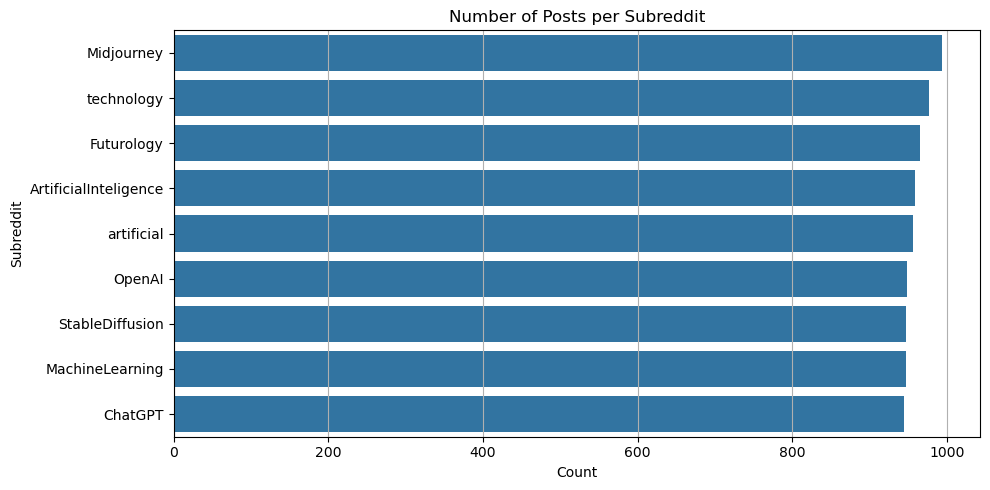

In [116]:
plt.figure(figsize=(10,5))
sns.countplot(data=posts, y="subreddit", order=posts["subreddit"].value_counts().index)
plt.title("Number of Posts per Subreddit")
plt.xlabel("Count")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

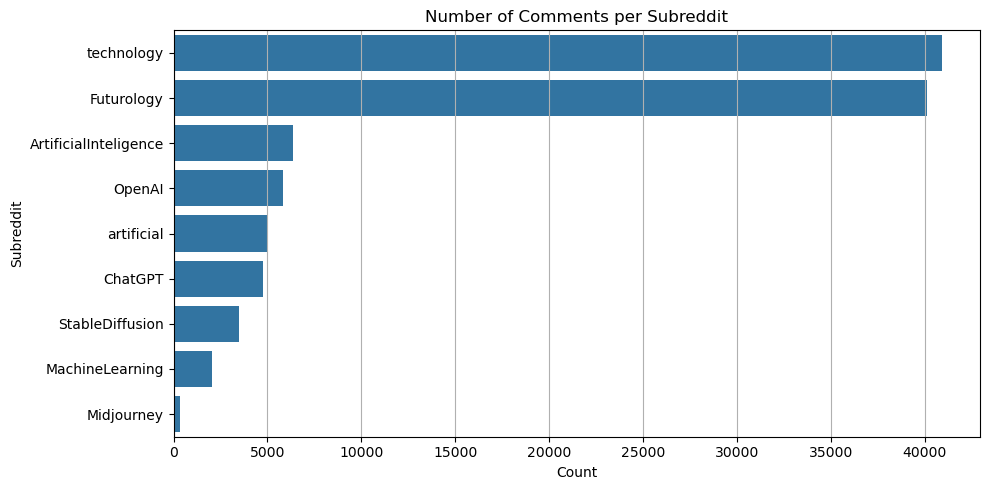

In [117]:
plt.figure(figsize=(10,5))
sns.countplot(data=comments, y="subreddit", order=comments["subreddit"].value_counts().index)
plt.title("Number of Comments per Subreddit")
plt.xlabel("Count")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

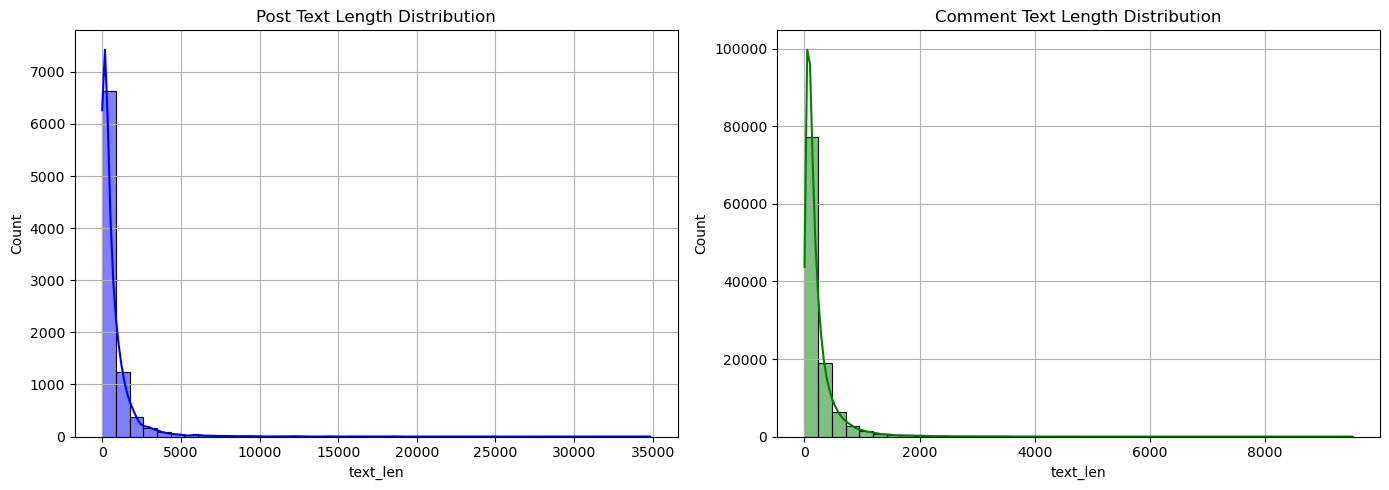

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(posts["text_len"], ax=ax[0], kde=True, bins=40, color="blue")
ax[0].set_title("Post Text Length Distribution")

sns.histplot(comments["text_len"], ax=ax[1], kde=True, bins=40, color="green")
ax[1].set_title("Comment Text Length Distribution")

plt.tight_layout()
plt.show()

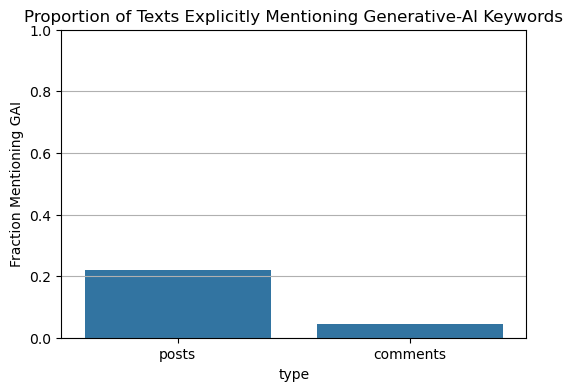

In [119]:
prop_df = pd.DataFrame({
    "type": ["posts", "comments"],
    "mentions_gai": [
        posts["mentions_gai"].mean(),
        comments["mentions_gai"].mean()
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=prop_df, x="type", y="mentions_gai")
plt.title("Proportion of Texts Explicitly Mentioning Generative-AI Keywords")
plt.ylabel("Fraction Mentioning GAI")
plt.ylim(0, 1)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/suryamothukuri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


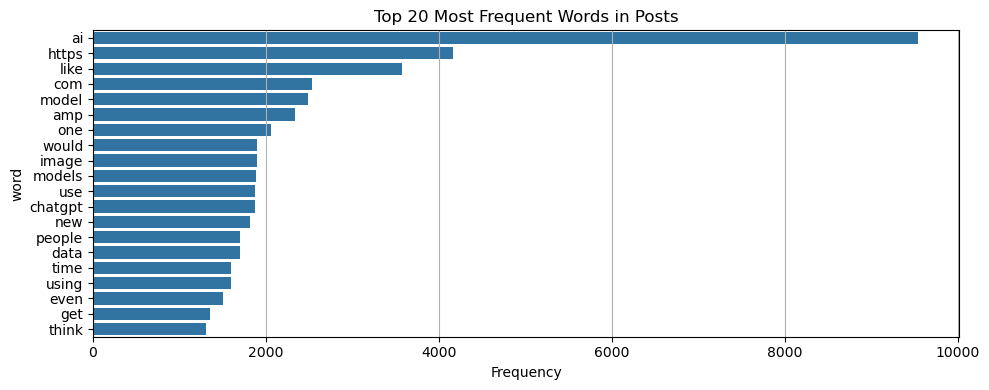

In [120]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download("stopwords")

stopwords = set(nltk.corpus.stopwords.words("english"))

# FIX: Convert to list or just use "english"
vectorizer = CountVectorizer(stop_words=list(stopwords), max_features=20)

X = vectorizer.fit_transform(posts["text"])

word_counts = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": X.sum(axis=0).A1
}).sort_values("count", ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(data=word_counts, x="count", y="word")
plt.title("Top 20 Most Frequent Words in Posts")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

## 7. Sentiment Analysis

To evaluate how online communities express attitudes toward generative AI, I apply sentiment analysis to both posts and comments. Because Reddit contains informal text with punctuation, emojis, and conversational language, I use the VADER sentiment analyzer, which is specifically optimized for social media contexts.

Each text item receives a compound sentiment score ranging from -1 (extremely negative) to +1 (extremely positive). I use these scores to compare sentiment across subreddits, examine trends over time, and contrast posts with comments to understand how discussions evolve within threads.

In [156]:
# 7.1 Initialize VADER and compute sentiment for posts + comments

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return sia.polarity_scores(text)["compound"]

# Compute sentiment
posts["sentiment"] = posts["text"].apply(get_sentiment)
comments["sentiment"] = comments["body"].apply(get_sentiment)

print("Done computing sentiment.")
posts[["text", "sentiment"]].head(3), comments[["body", "sentiment"]].head(3)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/suryamothukuri/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Done computing sentiment.


(                                                text  sentiment
 0  I cannot stand the "that's not xyz, it's just ...    -0.5994
 1  Guys, these chatGPT ads are getting out of han...     0.5837
 2           Excuse me? No custom instructions either    -0.2263,
                                                 body  sentiment
 0  *Wants an operating system, you know like run ...     0.4871
 1  &gt; *Can I just write a document in peace?\n\...     0.8412
 2  Don't you love when the bloated software that ...    -0.8763)

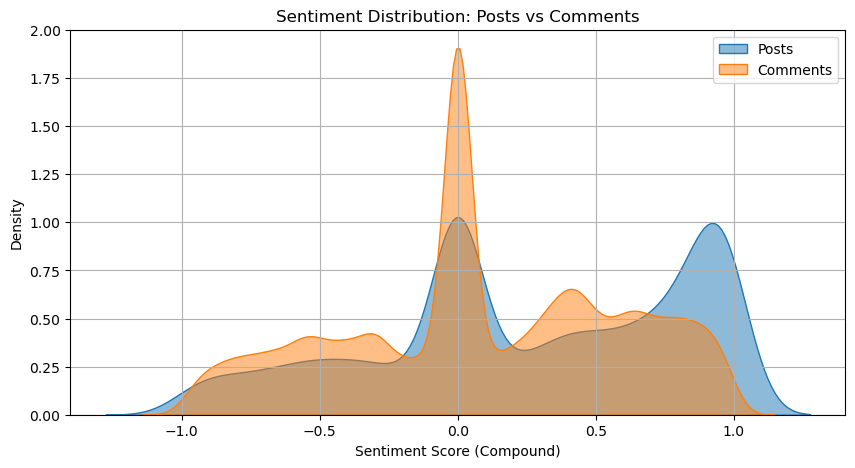

In [157]:
plt.figure(figsize=(10,5))
sns.kdeplot(posts["sentiment"], fill=True, label="Posts", alpha=0.5)
sns.kdeplot(comments["sentiment"], fill=True, label="Comments", alpha=0.5)
plt.title("Sentiment Distribution: Posts vs Comments")
plt.xlabel("Sentiment Score (Compound)")
plt.legend()
plt.show()

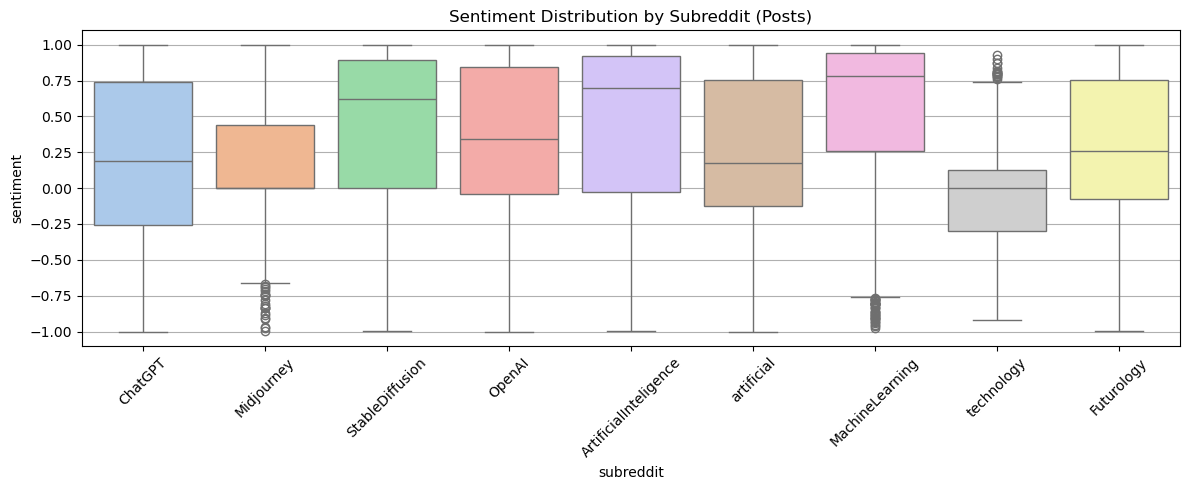

In [161]:
plt.figure(figsize=(12,5))

# Soft pastel palette for each subreddit
palette = sns.color_palette("pastel", n_colors=posts["subreddit"].nunique())

sns.boxplot(
    data=posts,
    x="subreddit",
    y="sentiment",
    palette=palette
)

plt.xticks(rotation=45)
plt.title("Sentiment Distribution by Subreddit (Posts)")
plt.tight_layout()
plt.show()

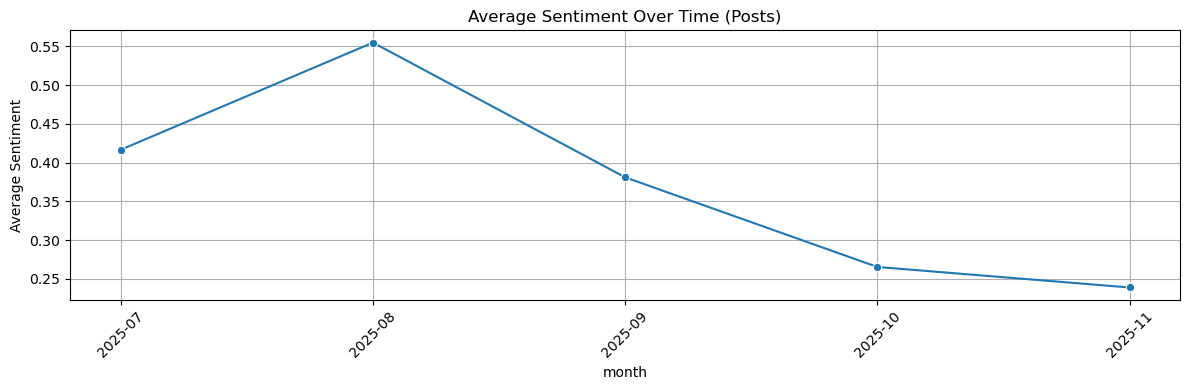

In [124]:
posts["month"] = posts["created_dt"].dt.to_period("M").astype(str)

monthly_sentiment = posts.groupby("month")["sentiment"].mean().reset_index()

plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_sentiment, x="month", y="sentiment", marker="o")
plt.xticks(rotation=45)
plt.ylabel("Average Sentiment")
plt.title("Average Sentiment Over Time (Posts)")
plt.tight_layout()
plt.show()

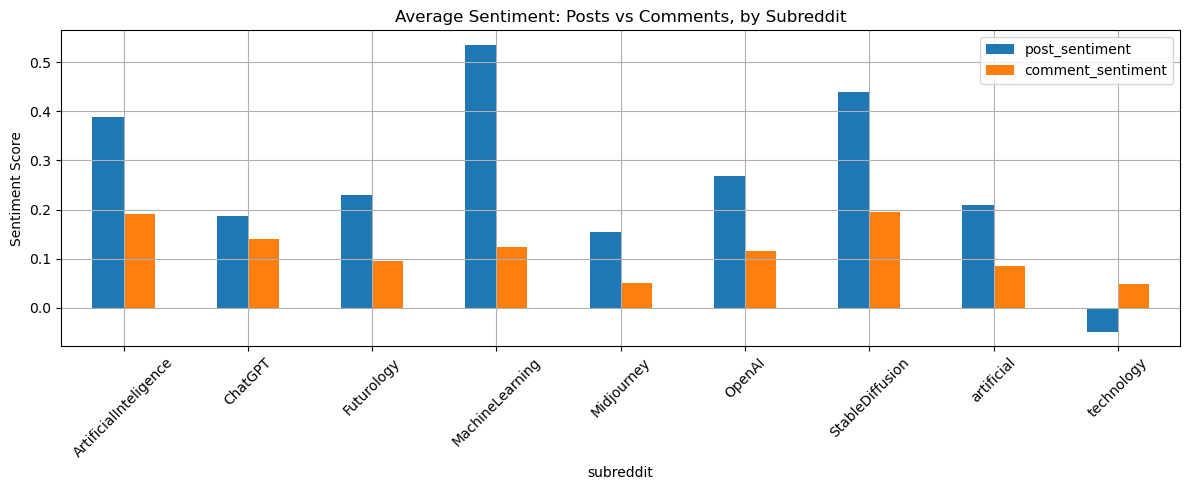

In [125]:
post_avg = posts.groupby("subreddit")["sentiment"].mean().rename("post_sentiment")
comment_avg = comments.groupby("subreddit")["sentiment"].mean().rename("comment_sentiment")

sent_compare = pd.concat([post_avg, comment_avg], axis=1).dropna()

sent_compare.plot(kind="bar", figsize=(12,5))
plt.title("Average Sentiment: Posts vs Comments, by Subreddit")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

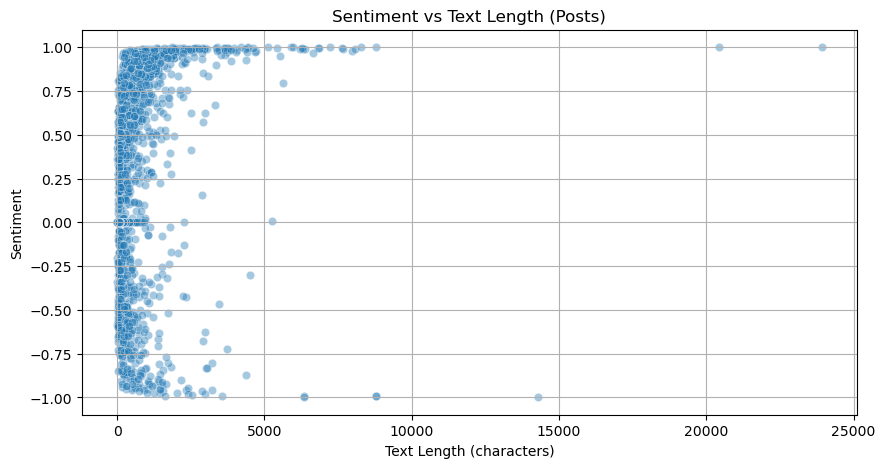

In [126]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=posts.sample(min(2000, len(posts))), 
    x="text_len", y="sentiment", alpha=0.4
)
plt.title("Sentiment vs Text Length (Posts)")
plt.xlabel("Text Length (characters)")
plt.ylabel("Sentiment")
plt.show()

## 8. Topic Modeling with BERTopic

To move beyond individual keywords and sentiment scores, I use BERTopic to uncover higher-level themes in how Reddit users discuss generative AI. BERTopic combines transformer-based sentence embeddings with clustering and class-based TF–IDF to generate interpretable topic representations.

In this project, I focus on posts that explicitly mention generative-AI tools (e.g., “ChatGPT”, “GPT-4”, “Midjourney”) and learn topics from this subset. This allows me to distinguish between different kinds of discourse, such as help-seeking, ethical concerns, technical troubleshooting, and creative experimentation.

In [127]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [128]:
# 8.3 Prepare a corpus of posts for topic modeling

# Reload cleaned posts to be safe
posts = pd.read_csv(CLEAN_POSTS_PATH, parse_dates=["created_dt"])

# Focus on posts that explicitly mention generative AI
posts_gai = posts[posts["mentions_gai"]].copy()

print("Posts mentioning GAI:", posts_gai.shape[0])

# Use the combined text field we created earlier
corpus = posts_gai["text"].dropna().astype(str).tolist()

# Optionally limit to a manageable subset (for speed)
MAX_DOCS = 3500
if len(corpus) > MAX_DOCS:
    posts_gai = posts_gai.sample(MAX_DOCS, random_state=42)
    corpus = posts_gai["text"].astype(str).tolist()

len(corpus)

Posts mentioning GAI: 1901


1901

In [129]:
# 8.4 Initialize embedding model, vectorizer, and BERTopic

# Sentence Transformer for embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Vectorizer for c-TF-IDF in BERTopic
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=10,      # ignore very rare words
    max_df=0.8      # ignore words that appear in almost all documents
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="english",
    top_n_words=10,
    nr_topics=None,    # let BERTopic decide; you can later reduce or merge if needed
    verbose=True
)

In [130]:
# 8.5 Fit BERTopic on the prepared corpus

topics, probs = topic_model.fit_transform(corpus)

# Attach topic labels back to posts_gai
posts_gai = posts_gai.reset_index(drop=True)
posts_gai["topic"] = topics

posts_gai[["subreddit", "created_dt", "topic", "text"]].head()

2025-12-01 04:23:37,235 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

2025-12-01 04:23:43,515 - BERTopic - Embedding - Completed ✓
2025-12-01 04:23:43,515 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-01 04:23:45,396 - BERTopic - Dimensionality - Completed ✓
2025-12-01 04:23:45,397 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-01 04:23:45,444 - BERTopic - Cluster - Completed ✓
2025-12-01 04:23:45,446 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-01 04:23:45,548 - BERTopic - Representation - Completed ✓


,subreddit,created_dt,topic,text
0,ChatGPT,2025-11-29 23:53:35+00:00,-1,"Guys, these chatGPT ads are getting out of han..."
1,ChatGPT,2025-11-29 22:54:25+00:00,6,I had ChatGPT create a Perpetual Motion Machin...
2,ChatGPT,2025-11-29 22:45:06+00:00,-1,Is ChatGPT being extra fussy and difficult abo...
3,ChatGPT,2025-11-29 22:28:18+00:00,-1,I just tried Google Gemini voice mode and it i...
4,ChatGPT,2025-11-29 22:27:57+00:00,13,Deeper Saved Memory Issue? So many months ago ...


In [131]:
# 8.6 Get topic summary table

topic_info = topic_model.get_topic_info()
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,696,-1_correct_llm_place_code,"[correct, llm, place, code, model, gt, data, r...",[It's been a big week for AI ; Here are 10 mas...
1,0,140,0_intelligence_human_companies_data,"[intelligence, human, companies, data, years, ...",[Why LLMs will inevitably fail in enterprise e...
2,1,116,1_fix_png_app_keeps,"[fix, png, app, keeps, connect, working, tried...",[Supermemory.ai - MCP Integration: Claude Desk...
3,2,114,2_style_image_reference_created,"[style, image, reference, created, images, ser...",[Crystalline fairies Prompt: «A polichrome fai...
4,3,109,3_model_github_training_reasoning,"[model, github, training, reasoning, performan...",[[R] Plain English outperforms JSON for LLM to...
5,4,92,4_openai_email_account_users,"[openai, email, account, users, 4o, times, use...",[OpenAI denies allegations ChatGPT is responsi...
6,5,74,5_image_png_style_preview,"[image, png, style, preview, width, webp, redd...",[Average Redditor in this sub (meme post wf in...
7,6,49,6_self_pattern_framework_state,"[self, pattern, framework, state, awareness, m...",[On Becoming Conscious: An Essay from the Insi...
8,7,46,7_2025_11_news_www,"[2025, 11, news, www, openai, google, daily, 1...",[One-Minute Daily AI News 11/28/2025 1. **MIT*...
9,8,37,8_safety_mental_health_data,"[safety, mental, health, data, framework, user...",[[R] ΔAPT: critical review aimed at maximizing...


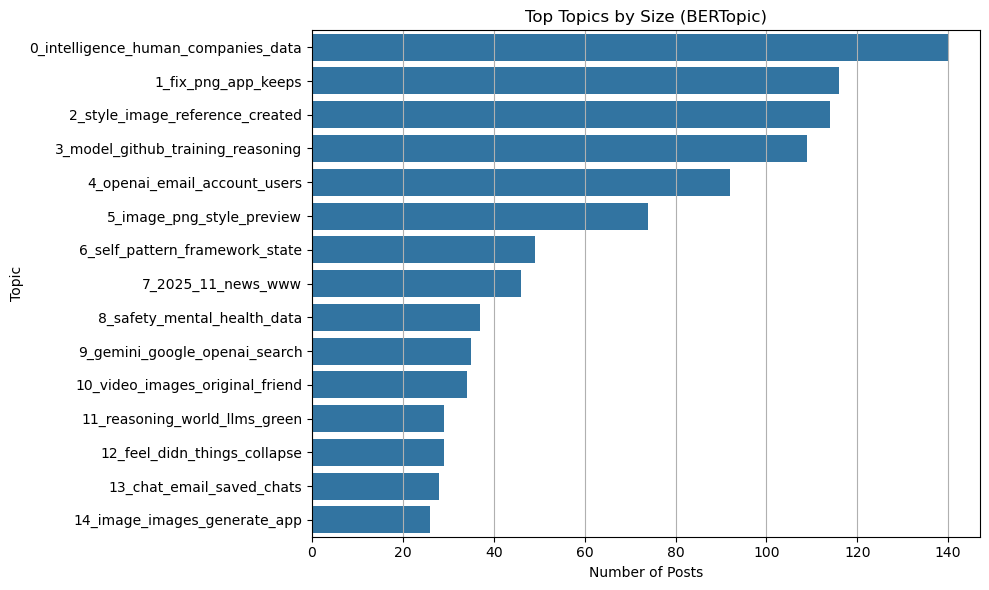

In [132]:
# Filter out outlier topic -1
topic_info_no_outlier = topic_info[topic_info["Topic"] != -1]

top_n = 15  # top 15 topics
top_topics = topic_info_no_outlier.head(top_n)

plt.figure(figsize=(10,6))
sns.barplot(data=top_topics, x="Count", y="Name")
plt.title("Top Topics by Size (BERTopic)")
plt.xlabel("Number of Posts")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

In [133]:
# 8.8 Helper: print top words for a given topic ID

def show_topic(topic_id, top_n=10):
    print(f"=== Topic {topic_id} ===")
    for word, weight in topic_model.get_topic(topic_id)[:top_n]:
        print(f"{word:20s} {weight:.4f}")

# Show top 5 non-outlier topics by size
for tid in top_topics["Topic"].head(5):
    show_topic(tid)
    print()

=== Topic 0 ===
intelligence         0.0215
human                0.0206
companies            0.0203
data                 0.0176
years                0.0161
real                 0.0151
need                 0.0149
llms                 0.0145
job                  0.0135
generative           0.0135

=== Topic 1 ===
fix                  0.0378
png                  0.0353
app                  0.0345
keeps                0.0327
connect              0.0302
working              0.0294
tried                0.0288
plus                 0.0275
request              0.0262
allowed              0.0259

=== Topic 2 ===
style                0.0620
image                0.0516
reference            0.0455
created              0.0442
images               0.0377
series               0.0372
generated            0.0337
profile              0.0328
tiny                 0.0313
www                  0.0308

=== Topic 3 ===
model                0.0378
github               0.0290
training             0.0256
reasoning

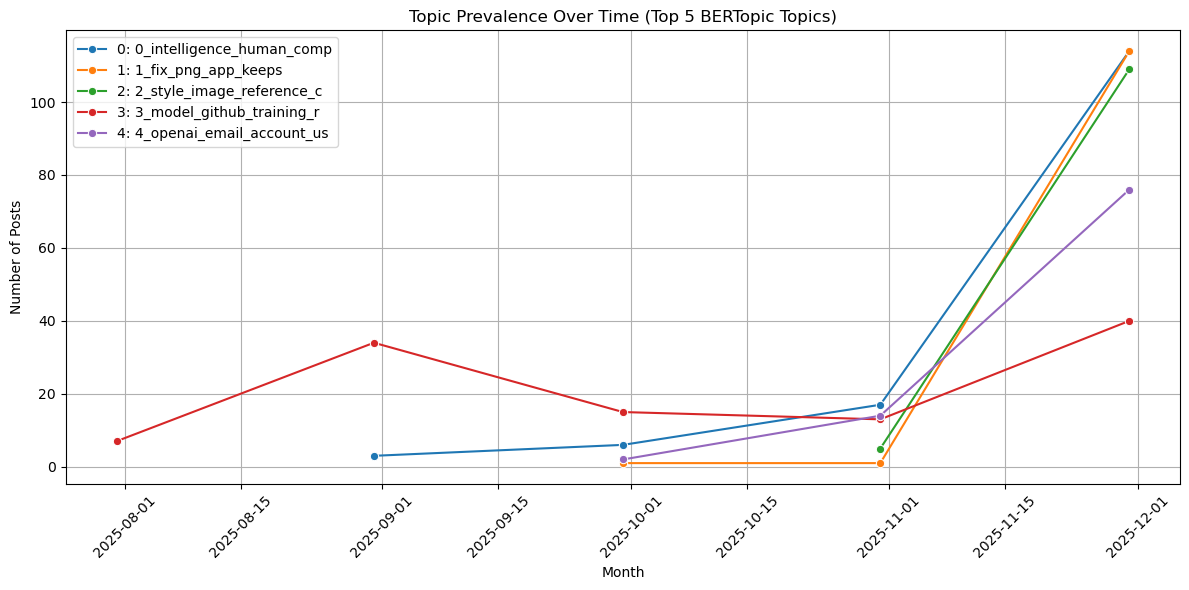

In [151]:
# Use Period month, not string
posts_gai["month"] = posts_gai["created_dt"].dt. to_period("M"). astype(str)

focus_topic_ids = top_topics["Topic"].tolist()

topic_month_counts = (
    posts_gai[posts_gai["topic"].isin(focus_topic_ids)]
    .groupby([pd.Grouper(key="created_dt", freq="M"), "topic"])
    .size()
    .reset_index(name="count")
    .rename(columns={"created_dt": "month"})
    .sort_values("month")
)

plt.figure(figsize=(12, 6))
for tid in focus_topic_ids[:5]:
    subset = topic_month_counts[topic_month_counts["topic"] == tid]
    label = topic_info.loc[topic_info["Topic"] == tid, "Name"].values[0]
    sns. lineplot(data=subset, x="month", y="count", marker="o", label=f"{tid}: {label[:25]}")

plt.xticks(rotation=45)
plt.title("Topic Prevalence Over Time (Top 5 BERTopic Topics)")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.tight_layout()
plt.legend()
plt.show()

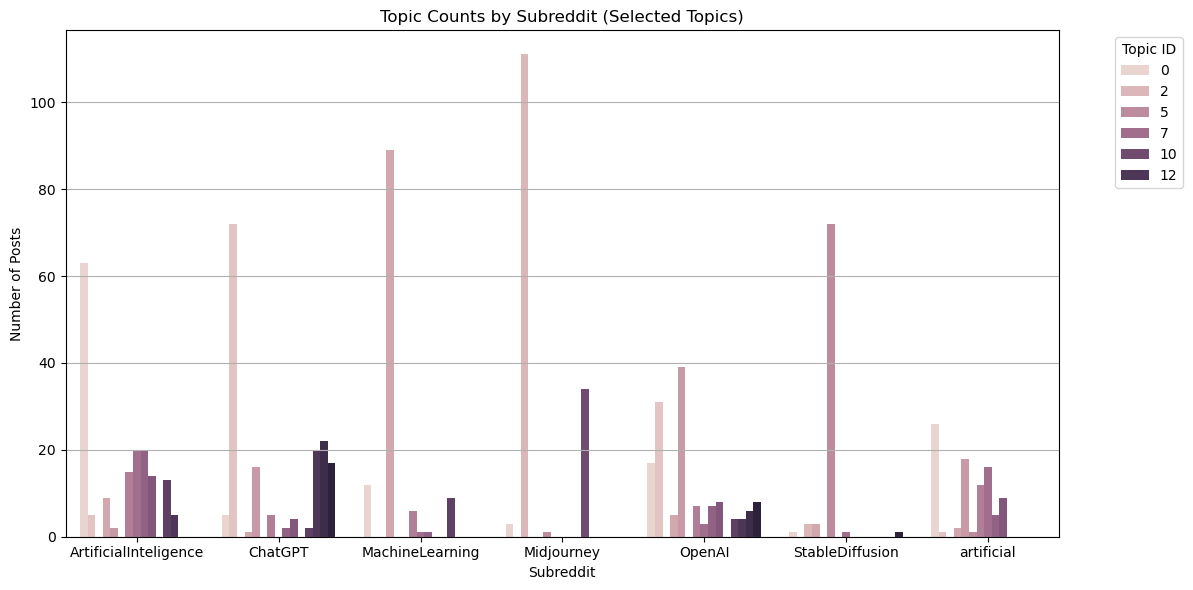

In [168]:
# 8.10 Topic distribution per subreddit for selected topics

topic_sub_counts = (
    posts_gai[posts_gai["topic"].isin(focus_topic_ids)]
    .groupby(["subreddit", "topic"])
    .size()
    .reset_index(name="count")
)

# Keep top 5–7 subreddits by volume
top_subs = posts_gai["subreddit"].value_counts().head(7).index
topic_sub_counts = topic_sub_counts[topic_sub_counts["subreddit"].isin(top_subs)]

plt.figure(figsize=(12,6))
sns.barplot(
    data=topic_sub_counts,
    x="subreddit",
    y="count",
    hue="topic"
)
plt.title("Topic Counts by Subreddit (Selected Topics)")
plt.ylabel("Number of Posts")
plt.xlabel("Subreddit")
plt.legend(
    title="Topic ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [170]:
# Ensure timestamp exists
posts_gai["month"] = posts_gai["created_dt"].dt.to_period("M").astype(str)

# Filter out outlier topic -1
posts_tm = posts_gai[posts_gai["topic"] != -1].copy()
posts_tm["topic_name"] = posts_tm["topic"].map(topic_name_map)

posts_tm.head()

,post_id,subreddit,title,selftext,score,num_comments,created_utc,url,over_18,text,created_dt,text_len,mentions_gai,topic,month,topic_name
1,1pa2ads,ChatGPT,I had ChatGPT create a Perpetual Motion Machine,Creating a device that harnesses perpetual mot...,0,11,1.764457e+09,https://www.reddit.com/r/ChatGPT/comments/1pa2...,False,I had ChatGPT create a Perpetual Motion Machin...,2025-11-29 22:54:25+00:00,9201,True,6,2025-11,6_self_pattern_framework_state
4,1pa1ovx,ChatGPT,Deeper Saved Memory Issue?,So many months ago I told ChatGPT to be more d...,4,7,1.764455e+09,https://www.reddit.com/r/ChatGPT/comments/1pa1...,False,Deeper Saved Memory Issue? So many months ago ...,2025-11-29 22:27:57+00:00,580,True,13,2025-11,13_chat_email_saved_chats
5,1pa1a7m,ChatGPT,What are some features you wish ChatGPT had?,Example: threads in chat,9,56,1.764454e+09,https://www.reddit.com/r/ChatGPT/comments/1pa1...,False,What are some features you wish ChatGPT had? E...,2025-11-29 22:10:03+00:00,69,True,29,2025-11,29_prompts_discovered_tool_useful
8,1p9zpp6,ChatGPT,has this happened to anyone: gpt losing context,[https://chatgpt.com/share/692b5dfe-c870-8001-...,1,2,1.764450e+09,https://www.reddit.com/r/ChatGPT/comments/1p9z...,False,has this happened to anyone: gpt losing contex...,2025-11-29 21:01:59+00:00,352,True,13,2025-11,13_chat_email_saved_chats
9,1p9yx7j,ChatGPT,Help- what has happened to chatgpt,I’ve actually just cancelled my subscription -...,7,2,1.764448e+09,https://www.reddit.com/r/ChatGPT/comments/1p9y...,False,Help- what has happened to chatgpt I’ve actual...,2025-11-29 20:28:04+00:00,976,True,14,2025-11,14_image_images_generate_app


In [171]:
# Group by month × topic
topic_month = (
    posts_tm.groupby(["month", "topic_name"])
    .size()
    .reset_index(name="count")
)

topic_month.head()

,month,topic_name,count
0,2025-07,28_agent_github_agents_research,1
1,2025-07,3_model_github_training_reasoning,7
2,2025-08,0_intelligence_human_companies_data,3
3,2025-08,11_reasoning_world_llms_green,3
4,2025-08,15_gt_safety_user_instructions,1


<Figure size 1400x600 with 0 Axes>

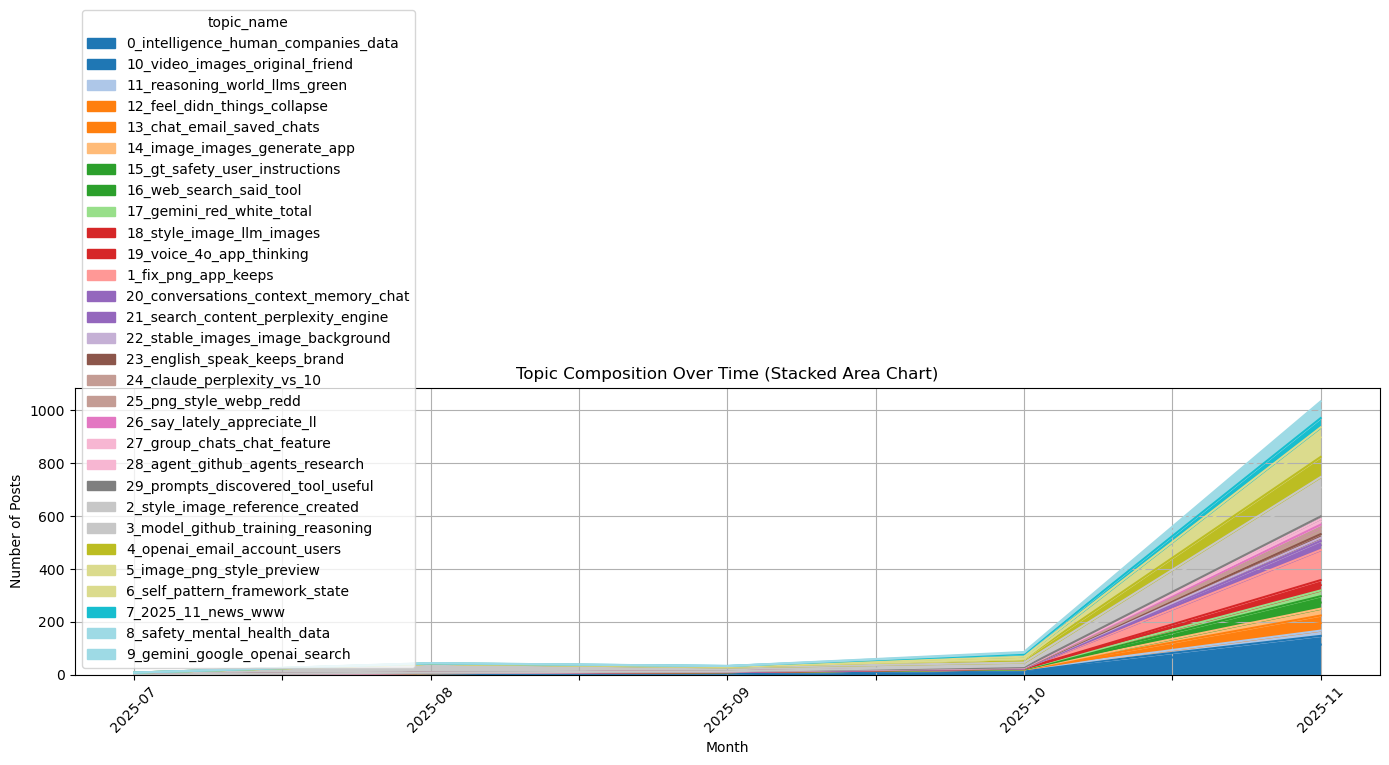

In [172]:
# Pivot to month × topic matrix
pivot_tm = topic_month.pivot(
    index="month",
    columns="topic_name",
    values="count"
).fillna(0)

pivot_tm_sorted = pivot_tm.sort_index()

plt.figure(figsize=(14, 6))
pivot_tm_sorted.plot(
    kind="area",
    stacked=True,
    figsize=(14, 6),
    colormap="tab20"
)
plt.title("Topic Composition Over Time (Stacked Area Chart)")
plt.ylabel("Number of Posts")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()